<a href="https://colab.research.google.com/github/omeriko35-dotcom/EDA-Assignment-3/blob/main/Omer_Ben_Artzi_work3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/omeriko35-dotcom/EDA-Assignment-3/blob/main/Omer_Ben_Artzi_work3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Work assignment number 3 - Final work (corrected resubmission)

**Student details:** Omer Ben Artzi - 211386883

**Data location:** https://www.kaggle.com/datasets/nudratabbas/healthcare-fraud-detection-dataset

**Course:** intro to data science

**Date of resubmission:** 22/09/2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('healthcare_fraud_detection.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 20)


,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


## 1. Dataset description and requirements

**Requirements**

* At least 1000 rows: the dataset has **10,000 rows** (10,000 > 1000).
* At least 8 features: the dataset has **20 columns**, of which 10 are numeric and 10 are categorical / identifiers.
* Mostly numerical variables: after removing identifiers, dates and the label, the analysis uses 8 numeric features (plus one engineered ratio), so the feature matrix used for PCA, clustering and anomaly detection is entirely numerical.
* Real-world dataset: the data describes medical insurance claims submitted by healthcare providers, published on Kaggle.
* No pre-labeled anomaly column: the raw file does contain a binary column `Is_Fraud`. To meet this requirement, **`Is_Fraud` is removed from the feature matrix before every step of the analysis** (EDA correlation, PCA, clustering, feature clustering and all three anomaly detectors). It is never used as an input, so all methods below are fully unsupervised.

**Where the dataset comes from**

The dataset is the "Healthcare Fraud Detection Dataset" published on Kaggle by the user nudratabbas. Each row is one insurance claim submitted by a healthcare provider for a patient.

**Why it was collected**

The dataset was built to support the study of healthcare insurance fraud: the goal is to find claims whose amounts, timing or provider behaviour do not match the typical claim, which is exactly an anomaly-detection problem.

**Who collected it**

It was uploaded to Kaggle by the user nudratabbas. The claim IDs run sequentially (C0000000, C0000001, ...) and provider IDs are anonymised (P0052, ...), which suggests the data is anonymised or partly synthetic; the original source of the claims is not documented on the Kaggle page.

**What each feature represents**

| Column | Type | Meaning | Used in feature matrix? |
|---|---|---|---|
| Provider_ID | identifier | Anonymised ID of the healthcare provider who submitted the claim | No (identifier) |
| Claim_ID | identifier | Unique ID of the claim | No (identifier) |
| Patient_Age | numeric | Age of the patient in years | Yes |
| Patient_Gender | categorical | Male / Female | No |
| Diagnosis_Code | categorical | ICD-10 diagnosis code (e.g. I10, E11.9) | No |
| Procedure_Code | numeric-looking code | CPT procedure code (e.g. 99213, 36415). Although stored as an integer, it is a categorical code, so it is excluded from the numeric analysis | No (categorical code) |
| Claim_Amount | numeric | Amount billed by the provider (USD) | Yes |
| Approved_Amount | numeric | Amount approved by the insurer (USD) | Yes |
| Insurance_Type | categorical | Medicaid / Medicare / Private / Self-Pay | No |
| Claim_Submission_Date | date | Date the claim was submitted | No |
| Days_Between_Service_and_Claim | numeric | Days from the service date to the claim submission | Yes |
| Number_of_Claims_Per_Provider_Monthly | numeric | How many claims the provider submits per month (provider activity level) | Yes |
| Provider_Specialty | categorical | Medical specialty of the provider (Cardiology, General Practice, ...) | No |
| Patient_State | categorical | US state of the patient | No |
| Claim_Status | categorical | Approved / Denied / Pending | No |
| Is_Fraud | binary label | 1 if the claim was flagged as fraud | **No (label, excluded)** |
| Length_of_Stay | numeric | Number of days of the hospital stay (0 for outpatient visits) | Yes |
| Visit_Type | categorical | Inpatient / Outpatient / Emergency | No |
| Chronic_Condition_Flag | binary numeric | 1 if the patient has a chronic condition | Yes |
| Prior_Visits_12m | numeric | Number of visits by the patient in the previous 12 months | Yes |
| Approval_Ratio (engineered) | numeric | Approved_Amount / Claim_Amount. Values far below 1 mean the insurer cut most of the bill | Yes |

**Possible limitations or biases in the data**

* The claim and provider IDs are anonymised and sequential, so the data may be synthetic or heavily processed; real fraud patterns may be simpler or noisier than in the file.
* Only 8 to 9 numeric features are available; important information such as the diagnosis, procedure, specialty and state is categorical and is not used by the numeric methods.
* Claim_Amount and Approved_Amount are strongly right-skewed (a small number of very large claims), which affects Z-score and K-Means.
* `Insurance_Type`, `Provider_Specialty` and `Prior_Visits_12m` each have 350 missing values (3.5% of the rows).
* The fraud label exists but is excluded, so there is no way to say inside this notebook whether a detected anomaly is a real fraud, a coding error or a legitimate expensive treatment.

## 2. Exploratory Data Analysis

In [2]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10000
Columns: 20


The dataset contains **10,000 rows and 20 columns** (10 numeric, 10 categorical / identifier / date).

**Missing values**

In [3]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print("\nShare of rows with at least one missing value:", round(df.isnull().any(axis=1).mean()*100, 2), "%")

Insurance_Type        350
Provider_Specialty    350
Prior_Visits_12m      350
dtype: int64

Share of rows with at least one missing value: 10.11 %


Three columns have missing values, 350 each (3.5% of the rows): `Insurance_Type`, `Provider_Specialty` and `Prior_Visits_12m`. Only `Prior_Visits_12m` is numeric and enters the feature matrix; it is imputed with the median in section 3.

**Data types**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Provider_ID                            10000 non-null  object 
 1   Claim_ID                               10000 non-null  object 
 2   Patient_Age                            10000 non-null  int64  
 3   Patient_Gender                         10000 non-null  object 
 4   Diagnosis_Code                         10000 non-null  object 
 5   Procedure_Code                         10000 non-null  int64  
 6   Claim_Amount                           10000 non-null  float64
 7   Approved_Amount                        10000 non-null  float64
 8   Insurance_Type                         9650 non-null   object 
 9   Claim_Submission_Date                  10000 non-null  object 
 10  Days_Between_Service_and_Claim         10000 non-null  int64  
 11  Num

**Statistical summary**

In [5]:
df.describe()

,Patient_Age,Procedure_Code,Claim_Amount,Approved_Amount,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Is_Fraud,Length_of_Stay,Chronic_Condition_Flag,Prior_Visits_12m
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,9650.000000
mean,49.755000,86905.21170,572.804406,475.514157,14.413800,68.628000,0.082900,2.19930,0.292000,3.026425
std,17.910144,14965.32496,406.202437,323.257165,8.489875,14.905872,0.275745,1.71046,0.454705,1.722789
min,1.000000,36415.00000,60.210000,50.350000,0.000000,42.000000,0.000000,0.00000,0.000000,0.000000
25%,37.750000,80053.00000,305.205000,257.200000,7.000000,60.000000,0.000000,1.00000,0.000000,2.000000
50%,50.000000,93000.00000,461.225000,388.370000,14.000000,66.000000,0.000000,2.00000,0.000000,3.000000
75%,62.000000,99213.00000,711.365000,598.347500,22.000000,72.000000,0.000000,3.00000,1.000000,4.000000
max,95.000000,99214.00000,6590.700000,4270.890000,29.000000,144.000000,1.000000,5.00000,1.000000,12.000000


Key facts from the summary: patients are between 1 and 95 years old (mean about 50). The median claim is about 461 USD but the maximum is 6,591 USD, more than 14 times the median, so the amount columns have a long right tail. Providers submit between 42 and 144 claims per month (median 66). Length of stay is 0 to 5 days, and 29% of the patients have a chronic condition.

**Building the numeric feature matrix (label removed)**

In [6]:
# Columns that must NOT be used as features:
#   Is_Fraud        - the pre-labelled anomaly column (assignment requires an unsupervised setting)
#   Procedure_Code  - a CPT code, categorical even though it is stored as an integer
drop_cols = ['Is_Fraud', 'Procedure_Code']

numeric_df = df.select_dtypes(include='number').drop(columns=drop_cols)

# Engineered feature: share of the claim that the insurer approved
numeric_df['Approval_Ratio'] = df['Approved_Amount'] / df['Claim_Amount']

print("Features used in the analysis:", list(numeric_df.columns))
print("Number of features:", numeric_df.shape[1])
assert 'Is_Fraud' not in numeric_df.columns

Features used in the analysis: ['Patient_Age', 'Claim_Amount', 'Approved_Amount', 'Days_Between_Service_and_Claim', 'Number_of_Claims_Per_Provider_Monthly', 'Length_of_Stay', 'Chronic_Condition_Flag', 'Prior_Visits_12m', 'Approval_Ratio']
Number of features: 9


**Correlation matrix**

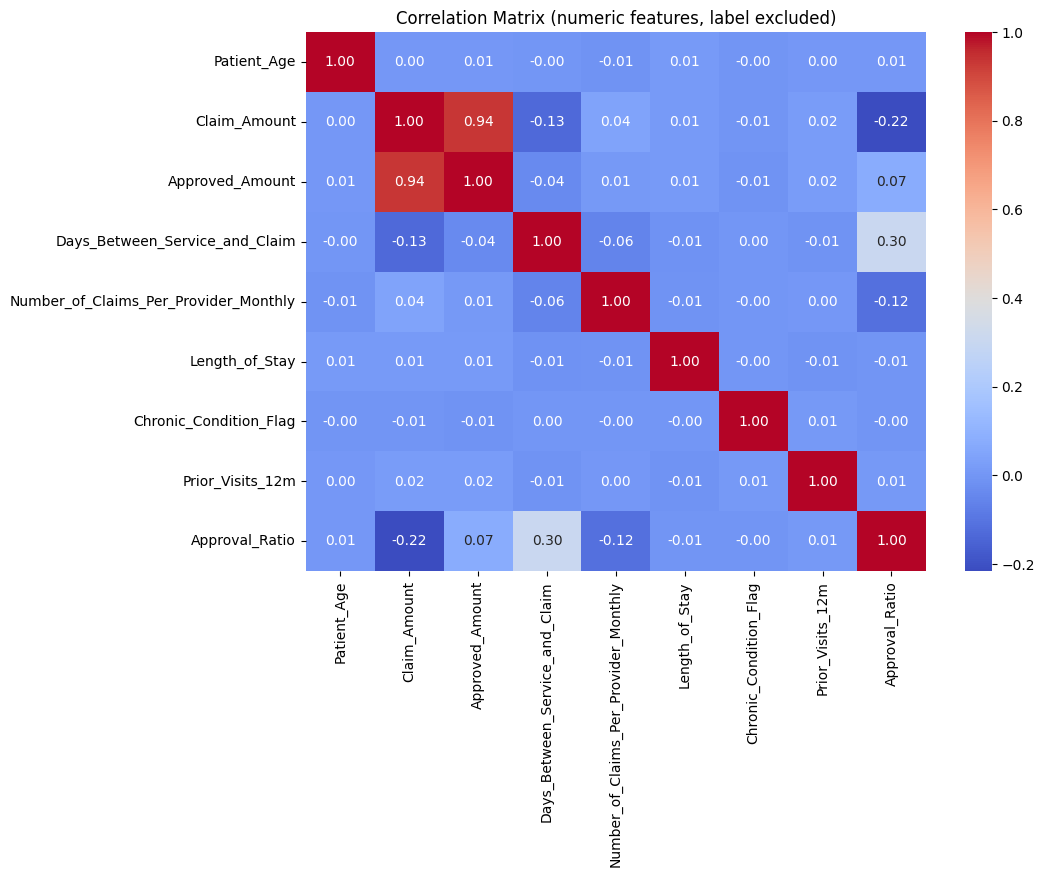

In [7]:
corr = numeric_df.corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Correlation Matrix (numeric features, label excluded)")
plt.show()

The only strong correlation is between `Claim_Amount` and `Approved_Amount` (r = 0.94), which is expected because the approved amount is a fraction of the billed amount. `Approval_Ratio` is moderately correlated with `Days_Between_Service_and_Claim` (r = 0.30, claims submitted quickly get a smaller share approved) and negatively with `Claim_Amount` (r = -0.22, large claims get a smaller share approved). All other pairs are between -0.13 and 0.07, so most of the features carry independent information, which limits how much PCA can compress the data.

**Distribution analysis (histograms)**

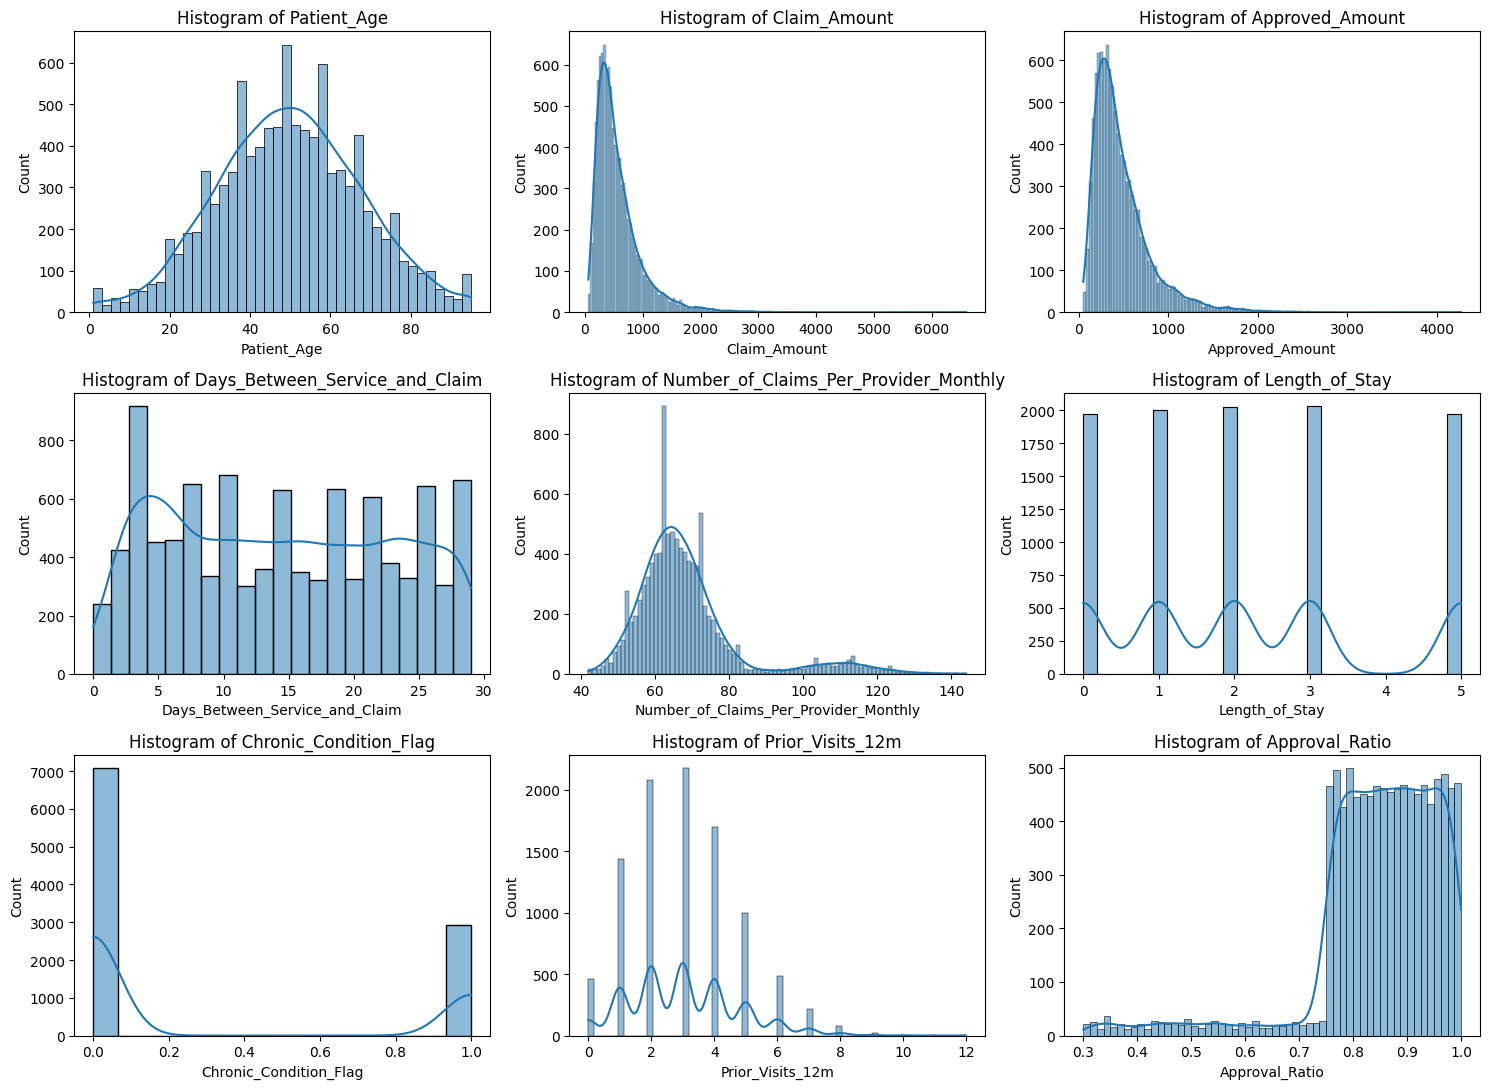

In [8]:
numeric_cols = numeric_df.columns

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(numeric_df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

**Boxplots**

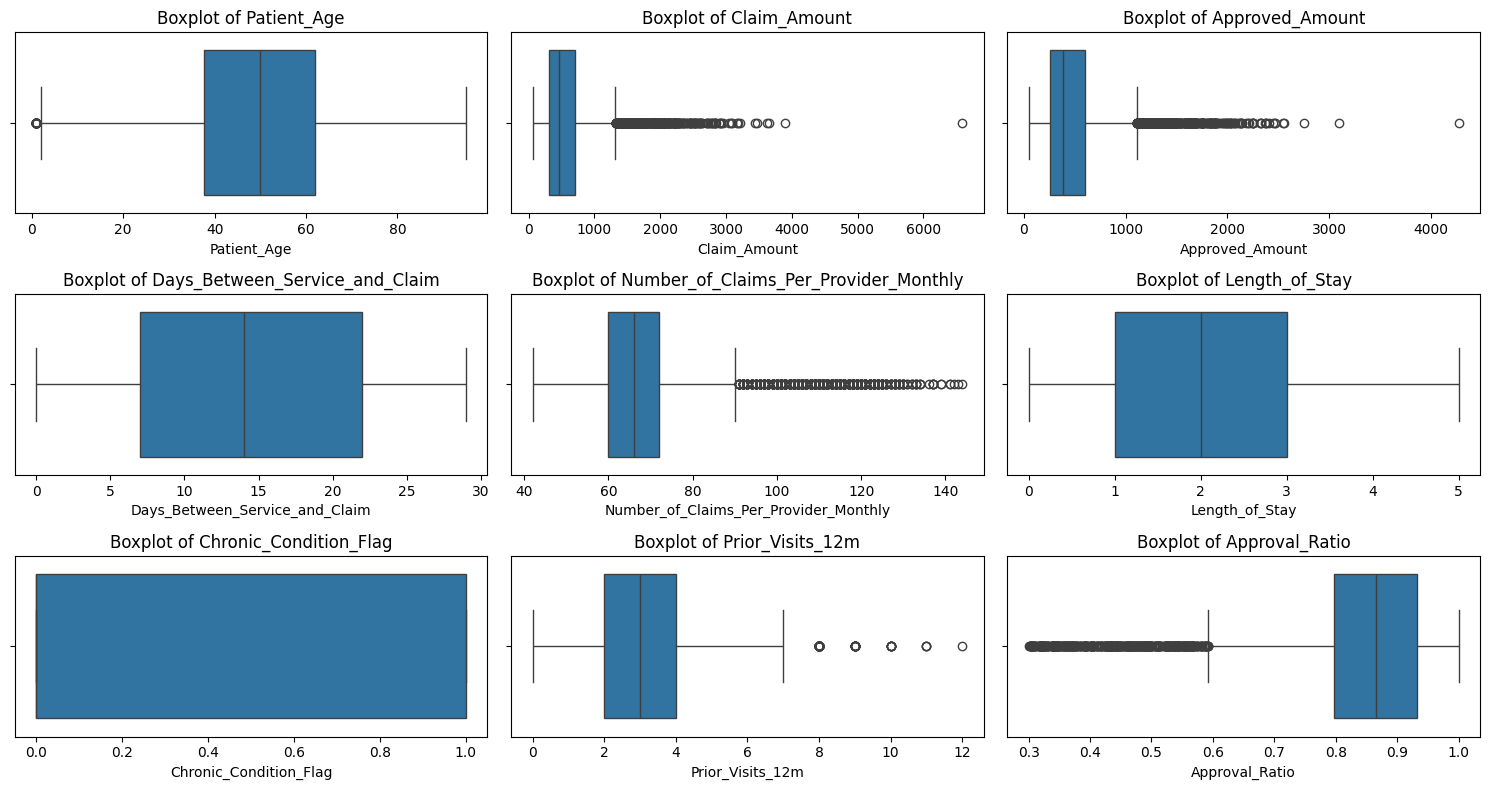

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(x=numeric_df[col].dropna(), ax=ax)
    ax.set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

**Skewness**

In [10]:
skewness = numeric_df.skew().sort_values(ascending=False)
print(skewness)

Claim_Amount                             2.410606
Approved_Amount                          2.090189
Number_of_Claims_Per_Provider_Monthly    1.906830
Chronic_Condition_Flag                   0.915062
Prior_Visits_12m                         0.537521
Length_of_Stay                           0.397082
Days_Between_Service_and_Claim           0.095071
Patient_Age                              0.009979
Approval_Ratio                          -1.915851
dtype: float64


**Kurtosis**

In [11]:
kurtosis = numeric_df.kurtosis().sort_values(ascending=False)
print(kurtosis)

Claim_Amount                             11.465984
Approved_Amount                           7.414441
Approval_Ratio                            5.079154
Number_of_Claims_Per_Provider_Monthly     4.175669
Prior_Visits_12m                          0.285010
Patient_Age                              -0.183660
Length_of_Stay                           -0.986033
Chronic_Condition_Flag                   -1.162895
Days_Between_Service_and_Claim           -1.247830
dtype: float64


**Outlier exploration**

`Claim_Amount` (skew 2.41, kurtosis 11.5) and `Approved_Amount` (skew 2.09, kurtosis 7.4) are the heavy-tailed features: a few claims are many times larger than the typical claim. `Number_of_Claims_Per_Provider_Monthly` is also right-skewed (skew 1.91, kurtosis 4.2): most providers submit 60 to 72 claims a month, but a small group submits up to 144. `Approval_Ratio` is left-skewed (skew -1.92, kurtosis 5.1): most claims get 80% to 95% approved, with a tail of claims where the insurer cut most of the bill. `Patient_Age`, `Days_Between_Service_and_Claim` and `Length_of_Stay` are close to uniform (negative kurtosis), so they have no outliers in the usual sense. `Chronic_Condition_Flag` is binary and its skewness only reflects the 29% / 71% split.

**Extreme values**

The boxplots show extreme observations mainly in the two amount columns and in the provider monthly claim count. In a claims dataset these can be legitimate expensive procedures (surgery, long hospitalisation), very busy providers, or inflated / fraudulent claims.

**Possible noise**

Small deviations in `Days_Between_Service_and_Claim` or `Prior_Visits_12m` are most likely random administrative variation and not anomalies.

**Measurement artifacts**

`Procedure_Code` looks numeric but is a code, so distances computed on it would be meaningless; this is why it was excluded. `Approval_Ratio` inherits any rounding or currency-conversion artifacts of the two amount columns.

**Data-entry problems**

Claims with `Approved_Amount` larger than `Claim_Amount` (ratio > 1), a length of stay of several days for an outpatient visit, or 0 days between service and claim could indicate entry errors. The checks below count such cases: no claim has a ratio above 1, but 2,743 "outpatient" visits have a length of stay above 0, and `Length_of_Stay` is distributed identically across visit types. This means `Length_of_Stay` and `Visit_Type` were generated independently, another sign that the dataset is synthetic, so a "stay" for an outpatient cannot be treated as an anomaly here.

In [12]:
print("Approved > Claimed (ratio > 1):", (numeric_df['Approval_Ratio'] > 1).sum())
print("Length_of_Stay > 0 for outpatient visits:",
      ((df['Visit_Type'] == 'Outpatient') & (df['Length_of_Stay'] > 0)).sum())
print("Claims submitted on the day of service:", (df['Days_Between_Service_and_Claim'] == 0).sum())

Approved > Claimed (ratio > 1): 0
Length_of_Stay > 0 for outpatient visits: 2743
Claims submitted on the day of service: 115


## 3. Dimensionality Reduction

### 3.1 Principal Component Analysis (PCA)

In [13]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print(numeric_df.isnull().sum().sort_values(ascending=False))

imputer = SimpleImputer(strategy='median')
numeric_imputed = pd.DataFrame(
    imputer.fit_transform(numeric_df),
    columns=numeric_df.columns
)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_imputed)
print("\nScaled feature matrix:", scaled_data.shape)

Prior_Visits_12m                         350
Patient_Age                                0
Claim_Amount                               0
Days_Between_Service_and_Claim             0
Approved_Amount                            0
Number_of_Claims_Per_Provider_Monthly      0
Length_of_Stay                             0
Chronic_Condition_Flag                     0
Approval_Ratio                             0
dtype: int64

Scaled feature matrix: (10000, 9)


Only `Prior_Visits_12m` has missing values (350). They were imputed with the median (3 visits) so that no rows are lost. The features were then standardised, because `Claim_Amount` (hundreds of USD) and `Chronic_Condition_Flag` (0/1) are on completely different scales and PCA is variance-based: without scaling, the amount columns would dominate every component.

In [14]:
pca = PCA()
pca_result = pca.fit_transform(scaled_data)

explained_variance = pca.explained_variance_ratio_
cum_variance = explained_variance.cumsum()

for i, (ev, cv) in enumerate(zip(explained_variance, cum_variance), start=1):
    print(f"PC{i}: {ev*100:5.1f}%   cumulative: {cv*100:5.1f}%")

PC1:  22.0%   cumulative:  22.0%
PC2:  14.8%   cumulative:  36.8%
PC3:  11.3%   cumulative:  48.2%
PC4:  11.2%   cumulative:  59.3%
PC5:  11.1%   cumulative:  70.4%
PC6:  10.9%   cumulative:  81.3%
PC7:  10.6%   cumulative:  92.0%
PC8:   7.8%   cumulative:  99.8%
PC9:   0.2%   cumulative: 100.0%


**Scree plot**

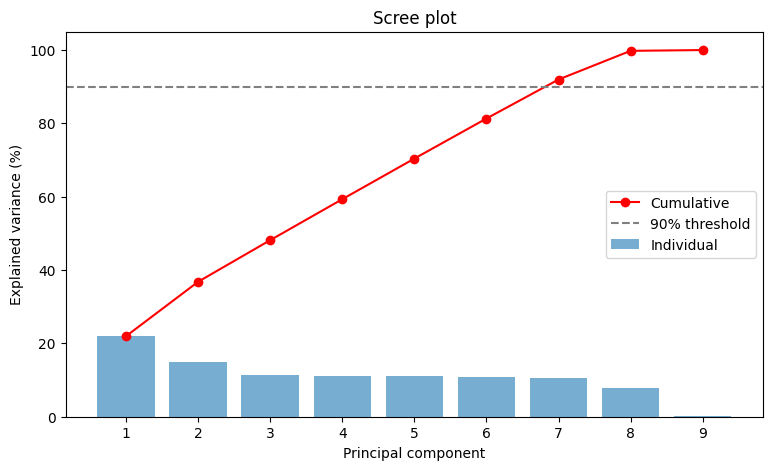

In [15]:
n_comp = len(explained_variance)

fig, ax1 = plt.subplots(figsize=(9,5))
ax1.bar(range(1, n_comp+1), explained_variance*100, alpha=0.6, label='Individual')
ax1.plot(range(1, n_comp+1), cum_variance*100, marker='o', color='red', label='Cumulative')
ax1.axhline(90, linestyle='--', color='gray', label='90% threshold')
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Explained variance (%)")
ax1.set_title("Scree plot")
ax1.set_xticks(range(1, n_comp+1))
ax1.legend()
plt.show()

**PCA projection into 2D**

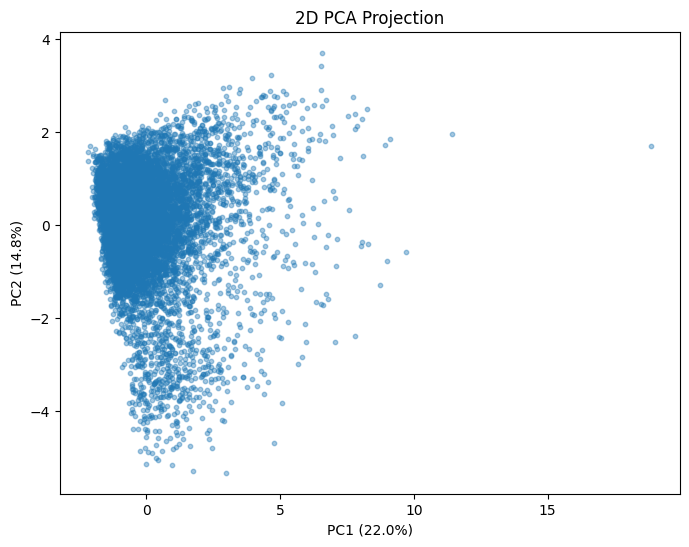

In [16]:
projection_2d = pca_result[:, :2]

plt.figure(figsize=(8,6))
plt.scatter(projection_2d[:,0], projection_2d[:,1], alpha=0.4, s=10)
plt.xlabel(f"PC1 ({explained_variance[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({explained_variance[1]*100:.1f}%)")
plt.title("2D PCA Projection")
plt.show()

**PCA projection into 3D**

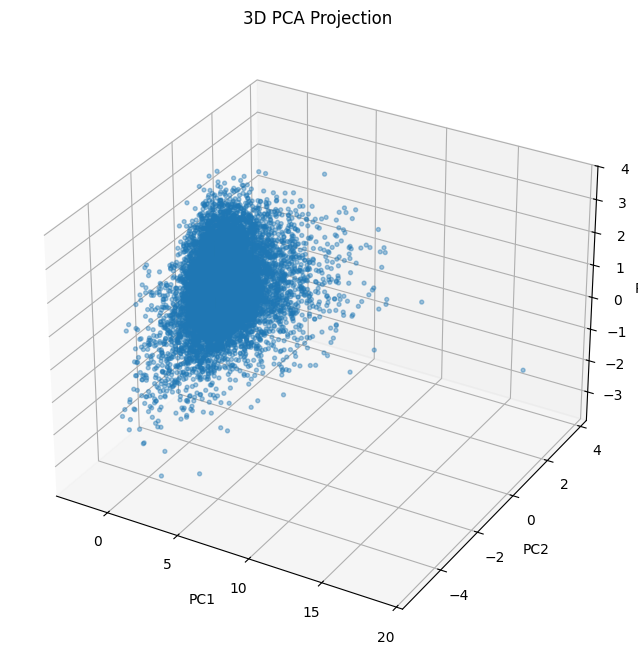

In [17]:
from mpl_toolkits.mplot3d import Axes3D

projection_3d = pca_result[:, :3]

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(projection_3d[:,0], projection_3d[:,1], projection_3d[:,2], alpha=0.4, s=8)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
plt.title("3D PCA Projection")
plt.show()

**How many components are needed?**

PC1 explains 22.0% of the variance, PC2 14.8% and PC3 11.3%. The cumulative variance reaches 90% only at 7 components, out of 9. The scree plot has no sharp elbow: after the first two components, PC3 to PC7 each explain a similar share (10.6% to 11.3%), and only PC9 (0.2%) is negligible because `Approved_Amount` is almost a linear function of `Claim_Amount`. This happens because the features are almost uncorrelated (section 2), so there is little redundancy for PCA to remove. A reasonable choice is to keep 7 components (92.0% of the variance); PCA is useful here mainly for visualisation and for finding the few correlated groups, not for compression.

**Information loss**

Keeping 2 components for visualisation retains only 36.8% of the variance (48.2% with 3), so the 2D and 3D scatter plots must be read as rough overviews. Keeping 7 components loses 8.0% of the variance, almost all of it patient-profile information spread over PC8.

**Correlated variables**

The loadings below show that `Claim_Amount`, `Approved_Amount` and `Approval_Ratio` load together on PC1: this is the only group of correlated variables in the data. The other features each dominate a separate component.

In [18]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(numeric_imputed.shape[1])],
    index=numeric_imputed.columns
)
loadings[['PC1','PC2','PC3']].round(3)

,PC1,PC2,PC3
Patient_Age,0.006,0.023,0.508
Claim_Amount,0.702,0.072,-0.008
Approved_Amount,0.666,0.281,-0.015
Days_Between_Service_and_Claim,-0.176,0.601,-0.085
Number_of_Claims_Per_Provider_Monthly,0.064,-0.319,-0.236
Length_of_Stay,0.020,-0.015,0.668
Chronic_Condition_Flag,-0.011,-0.012,-0.310
Prior_Visits_12m,0.024,0.015,-0.368
Approval_Ratio,-0.166,0.672,-0.028


**Interpretation of major components**

* **PC1 - claim size:** dominated by `Claim_Amount` (0.702) and `Approved_Amount` (0.666), with small negative loadings of `Days_Between_Service_and_Claim` (-0.176) and `Approval_Ratio` (-0.166). A high PC1 score is a large claim, submitted slightly faster and with a slightly smaller approved share.
* **PC2 - claim handling:** dominated by `Approval_Ratio` (0.672) and `Days_Between_Service_and_Claim` (0.601), with `Number_of_Claims_Per_Provider_Monthly` negative (-0.319). A high PC2 score is a claim that was submitted late, fully approved, by a low-volume provider; a low PC2 score is a claim submitted within days, largely rejected, by a very active provider. This axis is the most interesting one for fraud.
* **PC3 - patient profile:** dominated by `Length_of_Stay` (0.668) and `Patient_Age` (0.508), with `Prior_Visits_12m` (-0.368) and `Chronic_Condition_Flag` (-0.310) negative. It separates older patients with long stays from chronic patients with many prior visits.

**Local vs global structure**

PCA keeps the global direction of largest variance (claim size). Local structure, for example a small group of providers with an unusual mix of delay and activity, is spread over several later components and is not visible in the 2D plot.

**Cluster separation**

The 2D projection is a single dense cloud with a tail along PC1 (the large claims). There is no visible separation into groups, so any clusters found in section 4 will be partitions of a continuous cloud rather than well-separated groups.

**Stability**

PCA is deterministic: with the same preprocessing it always returns the same components, so the results are reproducible.

**Computational cost**

PCA on a 10,000 x 9 matrix takes a fraction of a second, so it is a cheap preprocessing step before the more expensive clustering and LOF computations.

**Interpretability**

PC1 has a clear meaning (claim size), but the later components mix several unrelated features with similar weights and are harder to name; the original features are easier to interpret than the components.

## 4. Clustering Analysis

**Choosing the number of clusters (elbow and silhouette)**

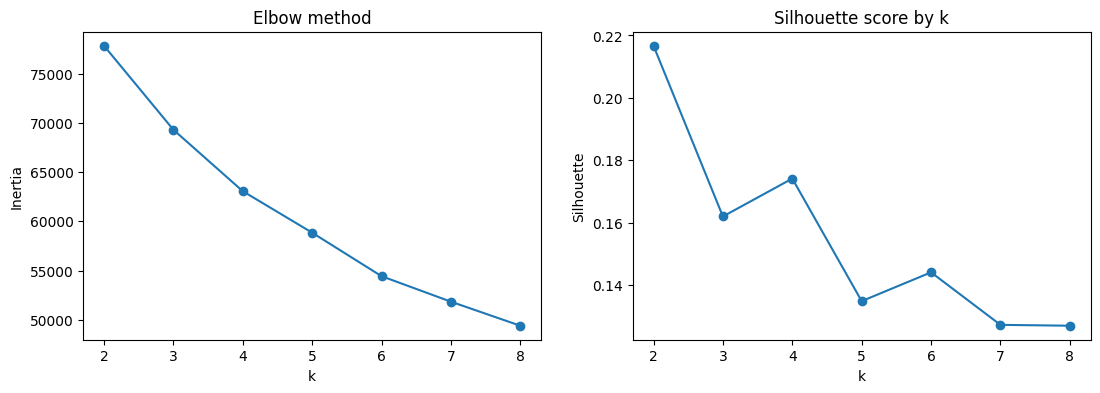

k=2: silhouette=0.217
k=3: silhouette=0.162
k=4: silhouette=0.174
k=5: silhouette=0.135
k=6: silhouette=0.144
k=7: silhouette=0.127
k=8: silhouette=0.127


In [19]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

inertia, sil = [], []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(scaled_data)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(scaled_data, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].plot(ks, inertia, marker='o'); axes[0].set_title("Elbow method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(ks, sil, marker='o'); axes[1].set_title("Silhouette score by k"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.show()

for k, s in zip(ks, sil):
    print(f"k={k}: silhouette={s:.3f}")

The silhouette is highest at k = 2 (0.217), then k = 4 (0.174); all values are low (below 0.22), confirming what the PCA plot suggested: the data is one continuous cloud with no strongly separated groups. The k = 2 solution simply splits the data on the binary `Chronic_Condition_Flag`, which is not informative. k = 4 is the next local maximum and produces clusters with a clear business meaning (see the profiling below), so it was kept for the rest of the section.

**K-Means**

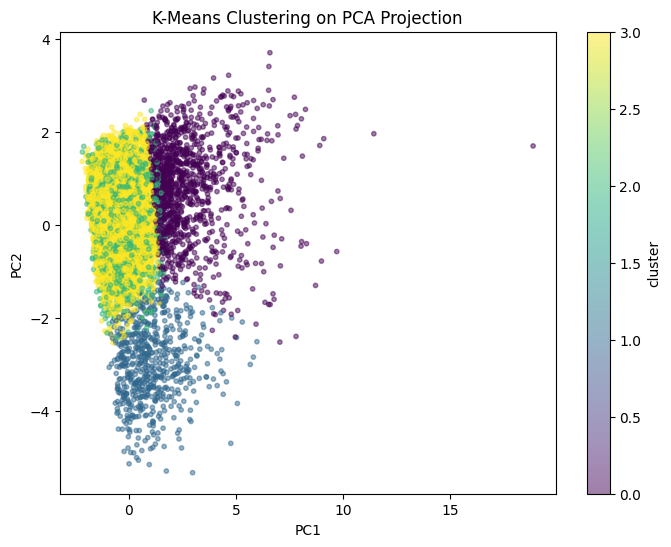

Cluster sizes: [1204  619 2475 5702]
Silhouette score (K-Means): 0.174


In [20]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(projection_2d[:,0], projection_2d[:,1], c=kmeans_labels, cmap='viridis', alpha=0.5, s=10)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("K-Means Clustering on PCA Projection")
plt.colorbar(label='cluster')
plt.show()

print("Cluster sizes:", np.bincount(kmeans_labels))
print("Silhouette score (K-Means):", round(silhouette_score(scaled_data, kmeans_labels), 3))

**Mathematical intuition:** K-Means partitions observations into K clusters by minimizing the sum of squared distances between each point and its cluster centroid, alternating between assigning points and recomputing centroids until convergence.

**Assumptions:** clusters are roughly spherical in the scaled space, have similar sizes and can be represented by their mean.

**Strengths and weaknesses:** fast and easy to interpret through the centroids; sensitive to initialisation, to the choice of K and to outliers such as the very large claims, which pull centroids toward them.

**DBSCAN**

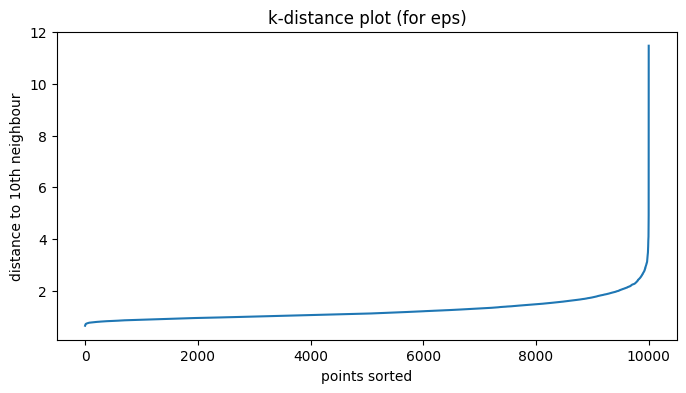

In [21]:
from sklearn.neighbors import NearestNeighbors

# k-distance plot to choose eps
nn = NearestNeighbors(n_neighbors=10).fit(scaled_data)
dist, _ = nn.kneighbors(scaled_data)
kdist = np.sort(dist[:, -1])
plt.figure(figsize=(8,4))
plt.plot(kdist); plt.ylabel("distance to 10th neighbour"); plt.xlabel("points sorted"); plt.title("k-distance plot (for eps)")
plt.show()

DBSCAN clusters: 2 | noise points: 921
-1     921
 0    2492
 1    6587
Name: count, dtype: int64


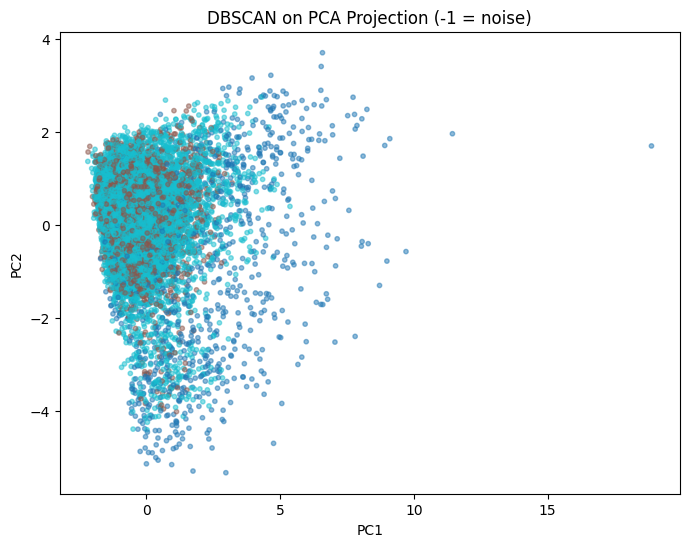

Silhouette score (DBSCAN, noise excluded): 0.163


In [22]:
dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(scaled_data)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()
print("DBSCAN clusters:", n_clusters_db, "| noise points:", n_noise)
print(pd.Series(dbscan_labels).value_counts().sort_index())

plt.figure(figsize=(8,6))
plt.scatter(projection_2d[:,0], projection_2d[:,1], c=dbscan_labels, cmap='tab10', alpha=0.5, s=10)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("DBSCAN on PCA Projection (-1 = noise)")
plt.show()

mask = dbscan_labels != -1
if n_clusters_db > 1:
    print("Silhouette score (DBSCAN, noise excluded):",
          round(silhouette_score(scaled_data[mask], dbscan_labels[mask]), 3))
else:
    print("Silhouette not defined: DBSCAN found fewer than 2 clusters")

With eps = 1.5 and min_samples = 10 DBSCAN finds 2 clusters (6,587 and 2,492 claims) and marks 921 claims (9.2%) as noise. The two clusters are the two values of `Chronic_Condition_Flag`: the binary feature creates two dense sheets separated by a fixed gap in the scaled space, so DBSCAN cannot merge them. Inside each sheet the data is one dense cloud, so DBSCAN finds no further structure and treats the tail of large claims and low approval ratios as noise. Here it behaves more like an anomaly detector than a clustering method.

**Mathematical intuition:** points with at least min_samples neighbours within radius eps are core points; clusters grow by connecting core points, and points that are not reachable from any core point are noise.

**Assumptions:** clusters are dense regions separated by sparser regions, all with a similar density.

**Strengths and weaknesses:** finds arbitrary shapes and flags noise without being told K; very sensitive to eps and min_samples and struggles when densities differ or when, as here, there is a single density peak.

**Hierarchical Clustering**

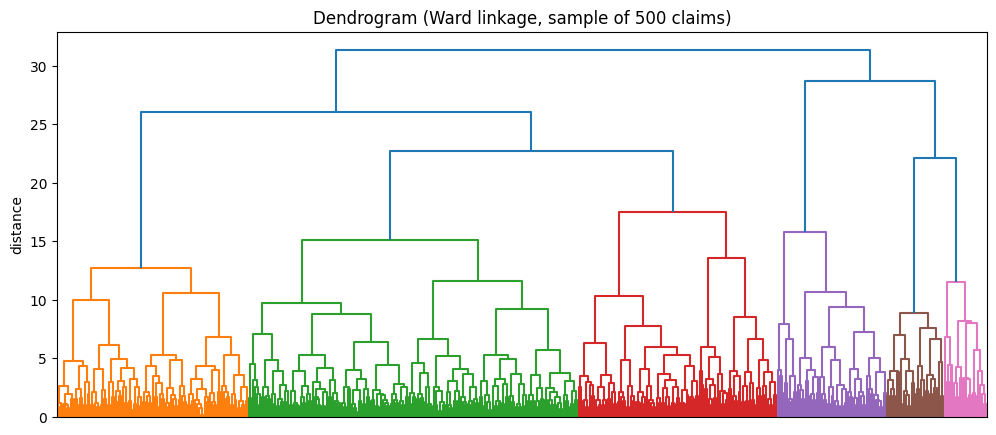

In [23]:
from scipy.cluster.hierarchy import dendrogram, linkage

# dendrogram on a sample (the full 10,000-point tree is unreadable)
sample_idx = np.random.RandomState(42).choice(len(scaled_data), 500, replace=False)
Z = linkage(scaled_data[sample_idx], method='ward')
plt.figure(figsize=(12,5))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.title("Dendrogram (Ward linkage, sample of 500 claims)")
plt.ylabel("distance")
plt.show()

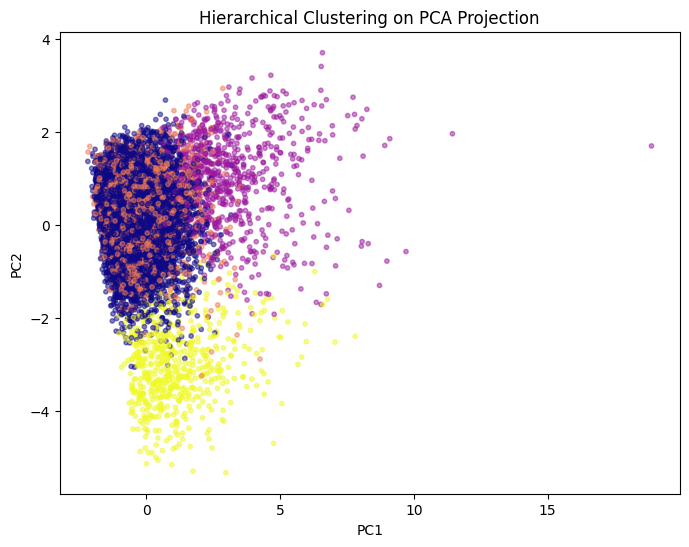

Cluster sizes: [6243  748 2437  572]
Silhouette score (Hierarchical): 0.162


In [24]:
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(projection_2d[:,0], projection_2d[:,1], c=hierarchical_labels, cmap='plasma', alpha=0.5, s=10)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Hierarchical Clustering on PCA Projection")
plt.show()

print("Cluster sizes:", np.bincount(hierarchical_labels))
print("Silhouette score (Hierarchical):", round(silhouette_score(scaled_data, hierarchical_labels), 3))

**Mathematical intuition:** each claim starts as its own cluster and the two closest clusters are merged repeatedly (Ward linkage merges the pair that increases the within-cluster variance the least), producing the tree shown in the dendrogram.

**Assumptions:** a meaningful nested structure exists, and (for Ward) clusters are compact and similar in size.

**Strengths and weaknesses:** no need to fix K in advance and the dendrogram shows the structure at every level; memory and time grow quadratically with the number of points, so it was run once and not tuned.

**Cluster profiling: what do the clusters represent?**

In [25]:
profile = numeric_imputed.copy()
profile['cluster'] = kmeans_labels

summary = profile.groupby('cluster').mean().round(2)
summary['size'] = profile['cluster'].value_counts().sort_index()
summary['share_%'] = (summary['size'] / len(profile) * 100).round(1)
summary

,Patient_Age,Claim_Amount,Approved_Amount,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Length_of_Stay,Chronic_Condition_Flag,Prior_Visits_12m,Approval_Ratio,size,share_%
cluster,,,,,,,,,,,
0,49.56,1346.06,1145.03,14.00,68.66,2.26,0.23,3.15,0.87,1204,12.0
1,48.45,852.07,410.86,2.97,77.71,2.22,0.28,3.01,0.49,619,6.2
2,49.69,453.00,394.72,15.29,67.98,2.18,1.00,3.01,0.87,2475,24.8
3,49.96,431.21,376.23,15.36,67.92,2.19,0.00,3.01,0.87,5702,57.0


In [26]:
# Categorical mix per cluster (the categoricals were not used for clustering; shown only for interpretation)
for col in ['Visit_Type', 'Insurance_Type', 'Claim_Status']:
    print(pd.crosstab(kmeans_labels, df[col], normalize='index').round(2), "\n")

Visit_Type  Emergency  Inpatient  Outpatient
row_0                                       
0                0.33       0.31        0.36
1                0.33       0.32        0.35
2                0.33       0.34        0.34
3                0.34       0.32        0.34 

Insurance_Type  Medicaid  Medicare  Private  Self-Pay
row_0                                                
0                   0.26      0.25     0.22      0.27
1                   0.25      0.26     0.25      0.25
2                   0.26      0.25     0.24      0.25
3                   0.25      0.25     0.26      0.25 

Claim_Status  Approved  Pending  Rejected
row_0                                    
0                 0.72     0.11      0.17
1                 0.18     0.34      0.48
2                 0.74     0.11      0.15
3                 0.75     0.10      0.15 



**Real-world interpretation of the K-Means clusters**

* **Cluster 3 (5,702 claims, 57.0%): routine claims of patients without a chronic condition.** Mean claim 431 USD, 87% approved, submitted after about 15 days, ordinary providers (68 claims / month). This is the baseline claim.
* **Cluster 2 (2,475 claims, 24.8%): routine claims of chronic patients.** Identical to cluster 3 in every column (453 USD, 87% approved, 15 days) except `Chronic_Condition_Flag` = 1 for every claim. The split between clusters 2 and 3 is driven only by the binary flag, not by claim behaviour.
* **Cluster 0 (1,204 claims, 12.0%): large legitimate claims.** Mean claim 1,346 USD (2.4 times the overall mean of 573 USD), but still 87% approved and 72% of the claims have status "Approved", the same as the routine clusters. These are expensive treatments that the insurer accepted.
* **Cluster 1 (619 claims, 6.2%): suspicious claims.** Above-average amount (852 USD), but only 49% approved on average, submitted within 3 days of service (against 14 to 15 for every other cluster), by very active providers (78 claims / month against 68). The status crosstab confirms the picture: only 18% of these claims are "Approved" and 48% are "Rejected", against 15% to 17% rejected elsewhere. This is the group an investigator would review first: fast, high-volume billing that the insurer largely cuts.

`Visit_Type` and `Insurance_Type` are spread identically (about a third / a quarter each) across all four clusters, so the clusters describe billing behaviour and patient chronicity, not the type of visit or the payer.

Hierarchical clustering with Ward linkage produced almost the same partition (adjusted Rand index 0.81; 92% of the claims fall in a matching cluster), which increases confidence that the four groups reflect real structure and not only the K-Means initialisation.

In [27]:
# agreement between K-Means and hierarchical partitions
from sklearn.metrics import adjusted_rand_score
print("Adjusted Rand index K-Means vs Hierarchical:", round(adjusted_rand_score(kmeans_labels, hierarchical_labels), 3))
print(pd.crosstab(kmeans_labels, hierarchical_labels))

Adjusted Rand index K-Means vs Hierarchical: 0.814
col_0     0    1     2    3
row_0                      
0       329  723   128   24
1        62    0    18  539
2       166    9  2291    9
3      5686   16     0    0


**Clustering features (transpose matrix)**

In [28]:
# rows = features, columns = claims. Standardised so that scale does not drive the grouping.
feature_matrix = scaled_data.T

feature_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
feature_labels = feature_kmeans.fit_predict(feature_matrix)

feature_clusters = pd.DataFrame({"Feature": numeric_imputed.columns, "Cluster": feature_labels})
print(feature_clusters.sort_values("Cluster"))

                                 Feature  Cluster
0                            Patient_Age        0
5                         Length_of_Stay        0
6                 Chronic_Condition_Flag        0
1                           Claim_Amount        1
4  Number_of_Claims_Per_Provider_Monthly        1
2                        Approved_Amount        1
7                       Prior_Visits_12m        1
3         Days_Between_Service_and_Claim        2
8                         Approval_Ratio        2


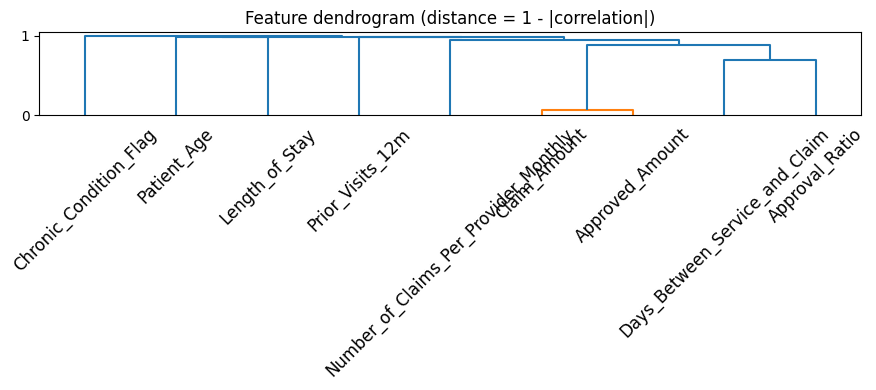

In [29]:
# Same idea with a correlation-based distance, which is easier to read for features
from scipy.cluster.hierarchy import linkage, dendrogram
corr_dist = 1 - np.abs(numeric_imputed.corr())
Zf = linkage(corr_dist.values[np.triu_indices(len(corr_dist), k=1)], method='average')
plt.figure(figsize=(9,4))
dendrogram(Zf, labels=numeric_imputed.columns.tolist(), leaf_rotation=45)
plt.title("Feature dendrogram (distance = 1 - |correlation|)")
plt.tight_layout(); plt.show()

**What information can be obtained by clustering the features?** Clustering the transposed matrix groups variables that behave similarly across the 10,000 claims, which exposes redundancy and natural feature "families" without looking at any label.

**Did the analysis reveal groups of related or redundant features?** Yes. K-Means on the transposed matrix puts `Claim_Amount` and `Approved_Amount` in the same cluster (together with `Number_of_Claims_Per_Provider_Monthly` and `Prior_Visits_12m`, the other right-skewed counts), and the two amounts are nearly redundant (r = 0.94). A second cluster holds `Days_Between_Service_and_Claim` and `Approval_Ratio`, the pair that also drives PC2 (r = 0.30). The correlation-based dendrogram shows the same two links and leaves every other feature on its own branch.

**Were there isolated features?** In the correlation dendrogram, `Patient_Age`, `Length_of_Stay`, `Chronic_Condition_Flag`, `Prior_Visits_12m` and `Number_of_Claims_Per_Provider_Monthly` join only at a distance close to 1, meaning each carries information shared with no other feature. The K-Means grouping of the transposed matrix puts age, stay and chronic flag together, but that reflects their similar (roughly symmetric) distributions rather than a real correlation.

**Did this reveal information not visible when clustering samples?** Yes. Sample clustering groups claims into business segments; feature clustering shows that the 9 features actually describe three things: money (the two amounts), claim handling (submission delay and approval share, plus provider activity) and patient profile (age, chronic condition, prior visits, stay).

**When is feature clustering useful?** In fraud detection, finance and sensor data it is used to remove redundant inputs, to build feature groups for interpretable models, and to spot a variable that suddenly stops behaving like its family (a sign of a data problem).

**Hidden structure:** the feature dendrogram makes explicit the three-block structure that the correlation heatmap only hints at.

**Cluster evaluation**

Average within-cluster variance (K-Means inertia) only measures compactness and always decreases with K, so it cannot choose K by itself (the elbow plot above has no clear bend). The silhouette score compares cohesion with separation; it was computed above for all three methods: K-Means 0.174, hierarchical 0.162, DBSCAN 0.163 (noise excluded). All are low, which honestly reflects that the claims form a continuum rather than separated groups; the highest value overall (0.217 at k = 2) only rewards the trivial split on the binary chronic flag.

**Why different algorithms produce different clusters:** each method uses a different notion of similarity: distance to a centroid (K-Means), local density (DBSCAN) and merge cost (Ward), so they cut the same continuous cloud in different places.

**Sensitivity to hyperparameters:** K changes the K-Means and hierarchical partitions completely; eps moves DBSCAN from "everything is noise" to "one giant cluster" within a small range, as the k-distance plot shows.

**Cluster geometry:** K-Means and Ward favour compact, roughly spherical groups; DBSCAN follows the shape of the dense region and separates the tail of large claims.

**Density-based vs centroid-based:** centroid methods force every claim, including the extreme ones, into a cluster; density methods leave them as noise, which is closer to how a fraud analyst would treat them.

**Situations where clustering may fail:** exactly this dataset is an example: no separated groups, heavy tails that pull centroids, and only 9 features of which several are almost uniform, so the clusters are useful segments but not "discovered" natural classes.

## 5. Multi-Dimensional Anomaly Detection

### 5.1 Z-Score

In [30]:
from scipy.stats import zscore

z_scores = pd.DataFrame(np.abs(zscore(numeric_imputed)), columns=numeric_imputed.columns)
z_anomalies = (z_scores > 3).any(axis=1).values
print("Number of anomalies (|z| > 3 in at least one feature):", z_anomalies.sum())

# which feature triggers the flag
print("\nFeatures that exceed |z| > 3 (count of rows):")
print((z_scores > 3).sum().sort_values(ascending=False))

Number of anomalies (|z| > 3 in at least one feature): 820

Features that exceed |z| > 3 (count of rows):
Approval_Ratio                           311
Number_of_Claims_Per_Provider_Monthly    291
Claim_Amount                             193
Approved_Amount                          188
Prior_Visits_12m                          31
Patient_Age                                0
Days_Between_Service_and_Claim             0
Chronic_Condition_Flag                     0
Length_of_Stay                             0
dtype: int64


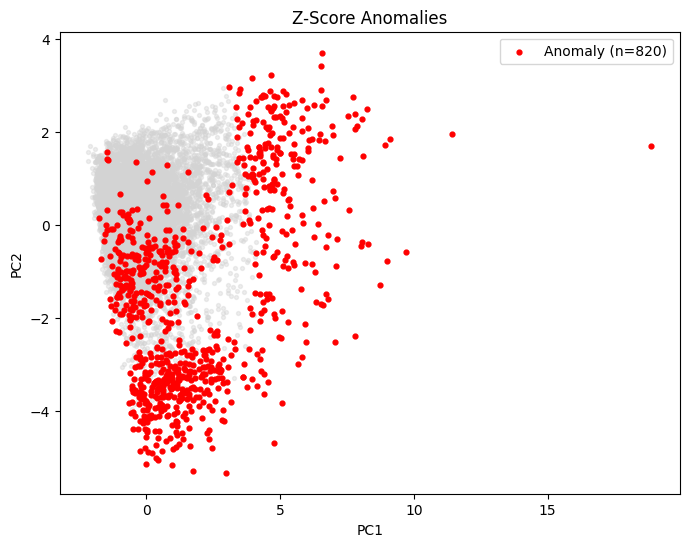

In [31]:
def plot_anomalies(mask, title):
    plt.figure(figsize=(8,6))
    plt.scatter(projection_2d[:,0], projection_2d[:,1], color='lightgray', alpha=0.4, s=8)
    plt.scatter(projection_2d[mask,0], projection_2d[mask,1], color='red', s=12, label=f'Anomaly (n={mask.sum()})')
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title(title); plt.legend(); plt.show()

plot_anomalies(z_anomalies, "Z-Score Anomalies")

The Z-score flags 820 claims (8.2%). The flags come from four features: `Approval_Ratio` (311 rows with a very low approved share), `Number_of_Claims_Per_Provider_Monthly` (291 rows from providers billing above about 113 claims a month), `Claim_Amount` (193) and `Approved_Amount` (188), plus 31 rows with many prior visits. Age, delay, stay and the chronic flag never exceed |z| > 3 because they are uniform or binary.

**Assumption of Gaussianity:** |z| > 3 corresponds to 0.3% of a normal distribution, but the amounts are strongly right-skewed (skew 2.4) and the approval ratio left-skewed (skew -1.9), so the rule flags many legitimate large claims, and in total 8.2% of the data instead of 0.3%.

**Why this may fail in high dimensions:** with 9 features, a claim is flagged if it is extreme in any one of them, so the number of flags grows with the number of features even when no claim is unusual overall.

**Feature-wise vs global detection:** Z-score looks at each feature alone; a claim with an ordinary amount but an impossible combination (for example a 5-day stay for an outpatient visit) is invisible to it.

### 5.2 Isolation Forest

Number of anomalies: 500


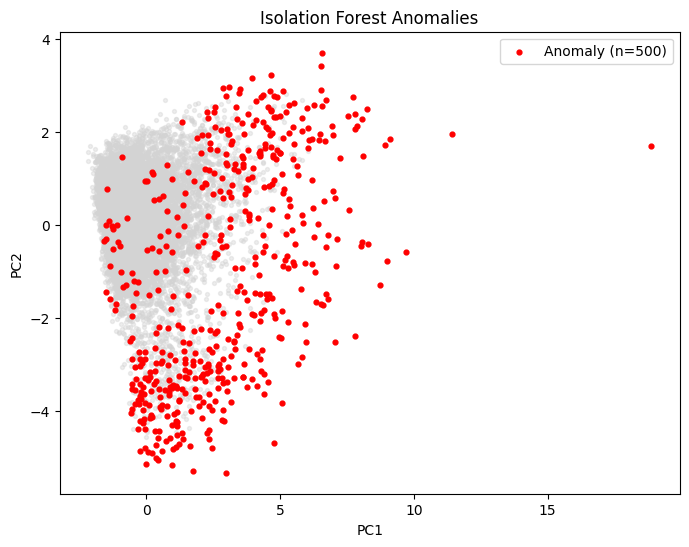

In [32]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_labels = iso_forest.fit_predict(scaled_data)
iso_anomalies = iso_labels == -1
print("Number of anomalies:", iso_anomalies.sum())

plot_anomalies(iso_anomalies, "Isolation Forest Anomalies")

**Isolation mechanism:** random trees split the data on random features and random thresholds; anomalies are isolated in few splits, so their average path length is short.

**Random partitioning:** because the splits are random, no distributional assumption is made and the method works on the raw (scaled) multivariate space.

**Contamination parameter:** contamination = 0.05 fixes the number of flagged claims at 5% (500 of 10,000). This is a choice, not a discovery: the method ranks claims by anomaly score and cuts at the 5% mark.

**Advantages in high dimensions:** it evaluates the claim as a whole, so combinations of moderately unusual values are caught, and it scales linearly with the number of rows.

### 5.3 Local Outlier Factor (LOF)

Number of anomalies: 500


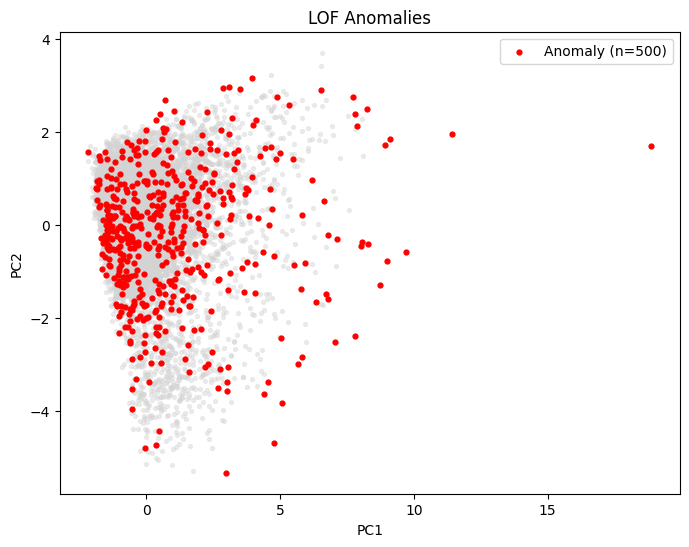

In [33]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(scaled_data)
lof_anomalies = lof_labels == -1
print("Number of anomalies:", lof_anomalies.sum())

plot_anomalies(lof_anomalies, "LOF Anomalies")

**Local density estimation:** LOF compares the density around a claim with the density around its 20 nearest neighbours; a ratio well above 1 means the claim sits in a sparser region than its neighbours.

**Neighbourhood effects:** the verdict depends only on the local neighbourhood, so a claim can be flagged even if its values are globally ordinary.

**Sensitivity to parameter k:** a small k makes LOF react to tiny local gaps (noise); a large k smooths the density and misses small anomalous groups. k = 20 is a standard middle value.

**Global vs local anomalies:** unlike the Z-score and Isolation Forest, LOF is designed for local anomalies, for example an ordinary-sized claim from a provider whose other claims all look different.

## 6. Comparison Section

**Overlap between the three methods (computed)**

In [34]:
z_set   = set(np.where(z_anomalies)[0])
iso_set = set(np.where(iso_anomalies)[0])
lof_set = set(np.where(lof_anomalies)[0])

print("Z-Score:", len(z_set))
print("Isolation Forest:", len(iso_set))
print("LOF:", len(lof_set))
print()
print("Z ∩ IsoForest:", len(z_set & iso_set))
print("Z ∩ LOF:", len(z_set & lof_set))
print("IsoForest ∩ LOF:", len(iso_set & lof_set))
print("All three:", len(z_set & iso_set & lof_set))
print()
print("Only Z-Score:", len(z_set - iso_set - lof_set))
print("Only IsoForest:", len(iso_set - z_set - lof_set))
print("Only LOF:", len(lof_set - z_set - iso_set))
print("Flagged by at least one method:", len(z_set | iso_set | lof_set))

overlap = pd.DataFrame({
    'Z-Score': z_anomalies, 'IsolationForest': iso_anomalies, 'LOF': lof_anomalies
}).astype(int)
print("\nJaccard similarity between methods:")
for a, b in [('Z-Score','IsolationForest'), ('Z-Score','LOF'), ('IsolationForest','LOF')]:
    inter = ((overlap[a]==1) & (overlap[b]==1)).sum()
    union = ((overlap[a]==1) | (overlap[b]==1)).sum()
    print(f"  {a} vs {b}: {inter/union:.2f}")

Z-Score: 820
Isolation Forest: 500
LOF: 500

Z ∩ IsoForest: 364
Z ∩ LOF: 115
IsoForest ∩ LOF: 149
All three: 87

Only Z-Score: 428
Only IsoForest: 74
Only LOF: 323
Flagged by at least one method: 1279

Jaccard similarity between methods:
  Z-Score vs IsolationForest: 0.38
  Z-Score vs LOF: 0.10
  IsolationForest vs LOF: 0.18


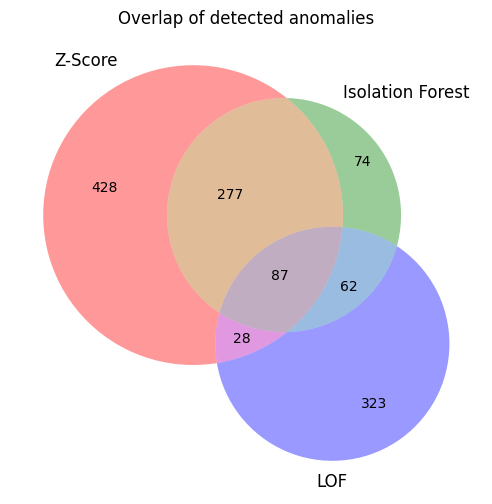

In [35]:
try:
    try:
        from matplotlib_venn import venn3
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "matplotlib-venn"], check=True)
        from matplotlib_venn import venn3
    plt.figure(figsize=(7,6))
    venn3([z_set, iso_set, lof_set], set_labels=('Z-Score', 'Isolation Forest', 'LOF'))
    plt.title("Overlap of detected anomalies")
    plt.show()
except Exception:
    # fallback without matplotlib-venn: bar chart of the regions
    regions = {
        'Z only': len(z_set - iso_set - lof_set),
        'IsoForest only': len(iso_set - z_set - lof_set),
        'LOF only': len(lof_set - z_set - iso_set),
        'Z & IsoForest': len((z_set & iso_set) - lof_set),
        'Z & LOF': len((z_set & lof_set) - iso_set),
        'IsoForest & LOF': len((iso_set & lof_set) - z_set),
        'All three': len(z_set & iso_set & lof_set),
    }
    plt.figure(figsize=(9,4))
    plt.bar(regions.keys(), regions.values())
    plt.xticks(rotation=30); plt.ylabel("claims"); plt.title("Overlap of detected anomalies")
    for i, v in enumerate(regions.values()):
        plt.text(i, v, str(v), ha='center', va='bottom')
    plt.show()

In [36]:
# Profile of the anomalies each method finds
prof = numeric_imputed.copy()
prof['Z'] = z_anomalies; prof['ISO'] = iso_anomalies; prof['LOF'] = lof_anomalies
cols = ['Claim_Amount','Approved_Amount','Approval_Ratio','Days_Between_Service_and_Claim',
        'Number_of_Claims_Per_Provider_Monthly','Length_of_Stay','Patient_Age']
pd.DataFrame({
    'all claims': prof[cols].mean(),
    'Z-Score': prof.loc[prof.Z, cols].mean(),
    'IsolationForest': prof.loc[prof.ISO, cols].mean(),
    'LOF': prof.loc[prof.LOF, cols].mean(),
    'all three': prof.loc[prof.Z & prof.ISO & prof.LOF, cols].mean(),
}).round(2)

,all claims,Z-Score,IsolationForest,LOF,all three
Claim_Amount,572.80,1134.10,1413.79,853.44,1944.50
Approved_Amount,475.51,769.13,970.88,658.87,1318.75
Approval_Ratio,0.85,0.67,0.67,0.82,0.70
Days_Between_Service_and_Claim,14.41,9.22,9.27,12.48,9.31
Number_of_Claims_Per_Provider_Monthly,68.63,88.19,82.27,74.29,84.51
Length_of_Stay,2.20,2.25,2.42,2.40,2.30
Patient_Age,49.76,49.23,50.30,50.40,56.37


**Which anomalies are shared between methods?**

Z-Score flags 820 claims, Isolation Forest 500 and LOF 500. Only 87 claims are flagged by all three methods, while 1,279 are flagged by at least one. The largest overlap is between Z-Score and Isolation Forest (364 claims, Jaccard 0.38): both react to the global tails, i.e. very large claims, very low approval ratios and very active providers. LOF shares only 149 claims with Isolation Forest (Jaccard 0.18) and 115 with Z-Score (Jaccard 0.10). The profile table shows why: the 87 consensus claims have a mean amount of 1,945 USD (3.4 times the overall mean), a 70% approval ratio and busy providers (85 claims / month), so they are extreme on every axis at once.

**Which anomalies are method-specific?**

* Only Z-Score (428): claims that are extreme in a single feature but otherwise typical. Their mean amount (1,134 USD) is lower than the Isolation Forest set, and a large part of them are flagged only because the provider's monthly volume or the approval ratio crosses the 3-sigma line.
* Only Isolation Forest (74): claims with a combination of moderately unusual values, for example a large amount together with a short submission delay (mean 9.3 days against 14.4) and an active provider, that no single feature makes extreme. On average the Isolation Forest set has the highest amounts (1,414 USD) and the lowest approval share (0.67) of the three methods.
* Only LOF (323): claims in locally sparse regions. Their mean amount (853 USD) and approval ratio (0.82) are close to the overall values, so they are not "big" claims but "odd" ones, unusual combinations of age, stay and prior visits that sit away from their neighbours.

**Sensitivity to scaling:** Isolation Forest and LOF were run on the standardised matrix; without scaling the amount columns (std of about 400) would dominate the distances and LOF would reduce to a one-dimensional amount detector. Z-score is scale-invariant by construction.

**Sensitivity to dimensionality:** Z-score gets more permissive as features are added (union of per-feature tails). LOF suffers from distance concentration in high dimensions; with 9 features this is still manageable. Isolation Forest is the least affected.

**Runtime considerations:** Z-score is instantaneous; Isolation Forest takes about a second (100 trees on subsamples); LOF must find 20 neighbours for each of the 10,000 claims and is the slowest, and would not scale to millions of claims without approximate neighbour search.

**Robustness to noise:** Isolation Forest is the most robust because the subsampled trees average out noise; LOF is the most fragile because a few noisy neighbours change the local density; Z-score is robust to noise but not to skew.

**Interpretability:** Z-score is fully explainable (the feature and the threshold are known for every flag). Isolation Forest gives a score but the reason requires extra tools. LOF is the hardest to explain to an insurance investigator.

**False positives vs false negatives:** Z-score is the most liberal (8.2% flagged) so it has the most false positives; the two contamination-based methods fix the rate at 5% and therefore trade false positives for false negatives depending on whether the true fraud rate is above or below 5%. The 87 claims flagged by all three are the most defensible candidates for manual review; the 428 Z-score-only claims are the least.

## 7. Critical Analysis and Reflection

**Why anomaly detection is fundamentally difficult**

An anomaly is defined only relative to what is "normal", and in this dataset normal is not known: a 6,000 USD claim is normal for cardiac surgery and anomalous for a blood test, but the numeric features do not encode the procedure. Without ground truth inside the analysis, every method returns a ranking, not an answer, and the three rankings disagree on most of their flags.

**Curse of dimensionality**

With 9 features the volume of the feature space is already large enough that the 10,000 claims are sparse. Adding features (for example one-hot encoded diagnosis codes) would make almost every claim "far" from every other and the Z-score union rule would flag a growing share of the data.

**Why distance becomes problematic in high dimensions**

As dimensions grow, the ratio between the nearest and the farthest neighbour tends to 1, so density-based methods like LOF and DBSCAN lose their contrast. The low silhouette scores (all below 0.22) and DBSCAN's inability to find anything beyond the split on the binary chronic flag are symptoms of this even at 9 dimensions.

**Difference between noise and anomaly**

Noise is random variation with no meaning (a claim submitted 15 instead of 14 days after service). An anomaly is a claim generated by a different process (a provider inflating amounts). Both look like outliers to the Z-score; only domain checks (approval ratio, visit type consistency) can separate them.

**The danger of assuming Gaussian distributions**

The amounts have skewness above 2 and kurtosis above 7, so the 3-sigma rule flags many legitimate expensive claims. A log transform of the amounts or a robust score (median / MAD) would be more appropriate.

**Why visualization may be misleading after dimensionality reduction**

PC1 and PC2 keep only 36.8% of the variance. Many LOF anomalies appear inside the dense cloud in the 2D plot because what makes them unusual lives in PC4 to PC9; conversely the tail along PC1 looks like a separate group but is just the continuous right tail of the amounts.

**Ethical considerations**

* **False alarms:** flagging a legitimate claim as fraud delays payment to a provider and treatment to a patient; the 500 flagged claims of Isolation Forest include, by construction, ordinary expensive treatments.
* **Surveillance applications:** provider-level features (monthly claim count) make the analysis a form of monitoring of doctors; using it without transparency could penalise busy specialists.
* **Medical applications:** the features (age, chronic condition, prior visits) describe patients; an anomaly score must never become a reason to deny care, only a trigger for a human review.
* **Cybersecurity applications:** the same techniques detect intrusions; there too, an unexplainable LOF flag is hard to act on, and the analyst needs the interpretable Z-score reasons alongside the multivariate score.

## 8. Final Visualization Dashboard

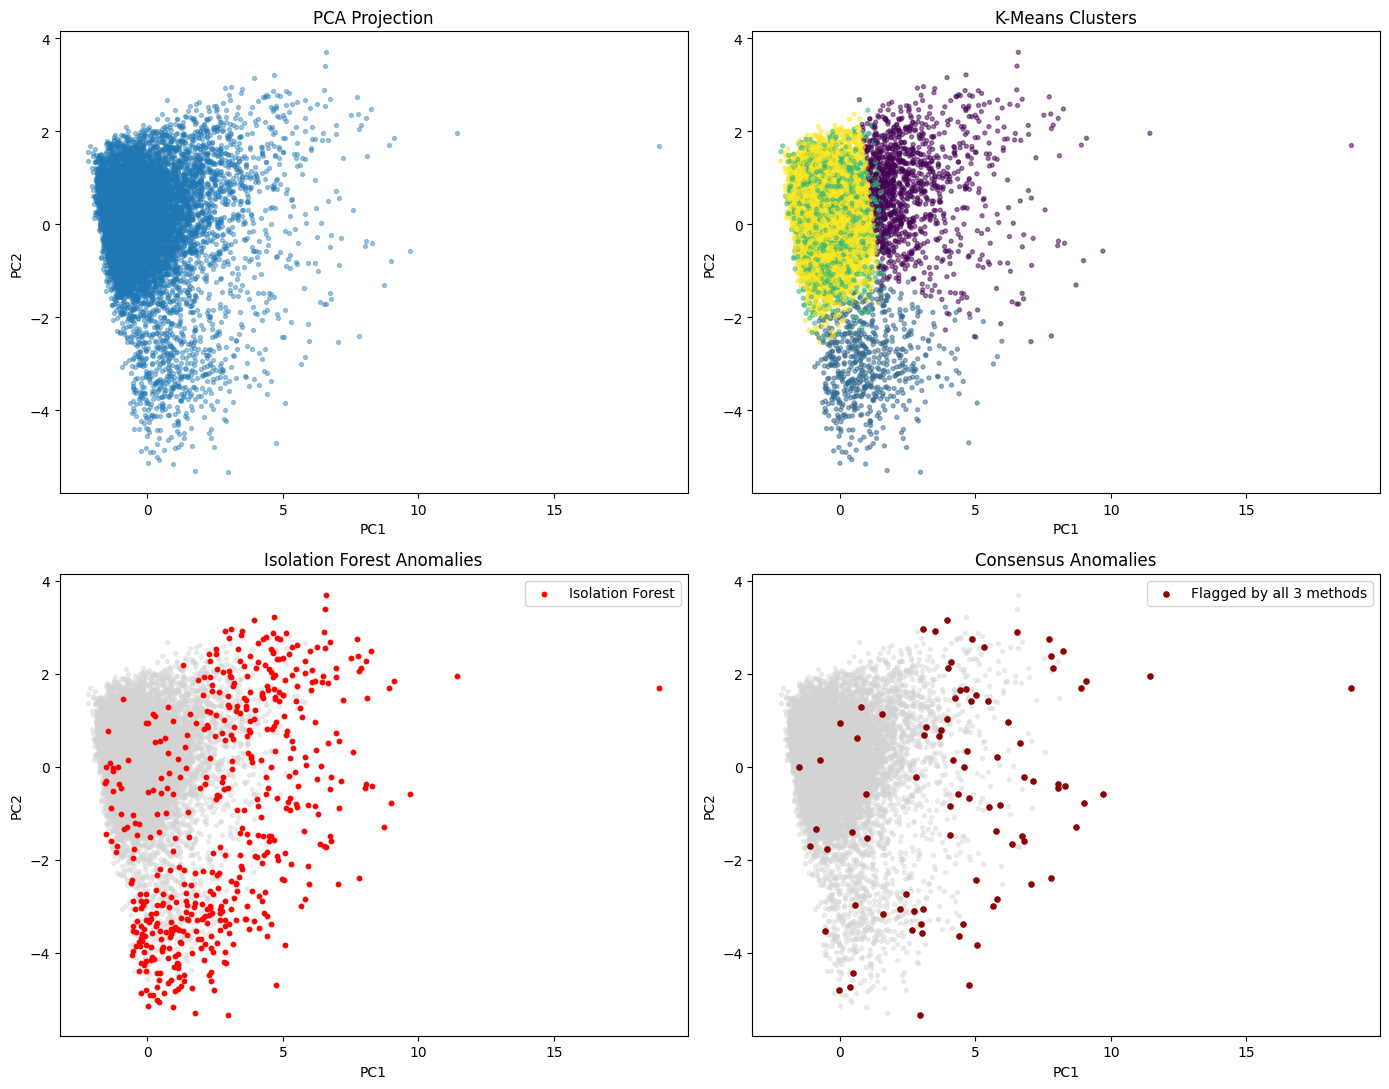

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

axes[0,0].scatter(projection_2d[:,0], projection_2d[:,1], alpha=0.4, s=8)
axes[0,0].set_title("PCA Projection")

sc = axes[0,1].scatter(projection_2d[:,0], projection_2d[:,1], c=kmeans_labels, cmap='viridis', alpha=0.5, s=8)
axes[0,1].set_title("K-Means Clusters")

axes[1,0].scatter(projection_2d[:,0], projection_2d[:,1], color='lightgray', alpha=0.4, s=8)
axes[1,0].scatter(projection_2d[iso_anomalies,0], projection_2d[iso_anomalies,1], color='red', s=10, label='Isolation Forest')
axes[1,0].legend(); axes[1,0].set_title("Isolation Forest Anomalies")

both = z_anomalies & iso_anomalies & lof_anomalies
axes[1,1].scatter(projection_2d[:,0], projection_2d[:,1], color='lightgray', alpha=0.4, s=8)
axes[1,1].scatter(projection_2d[both,0], projection_2d[both,1], color='darkred', s=14, label='Flagged by all 3 methods')
axes[1,1].legend(); axes[1,1].set_title("Consensus Anomalies")

for ax in axes.ravel():
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout(); plt.show()

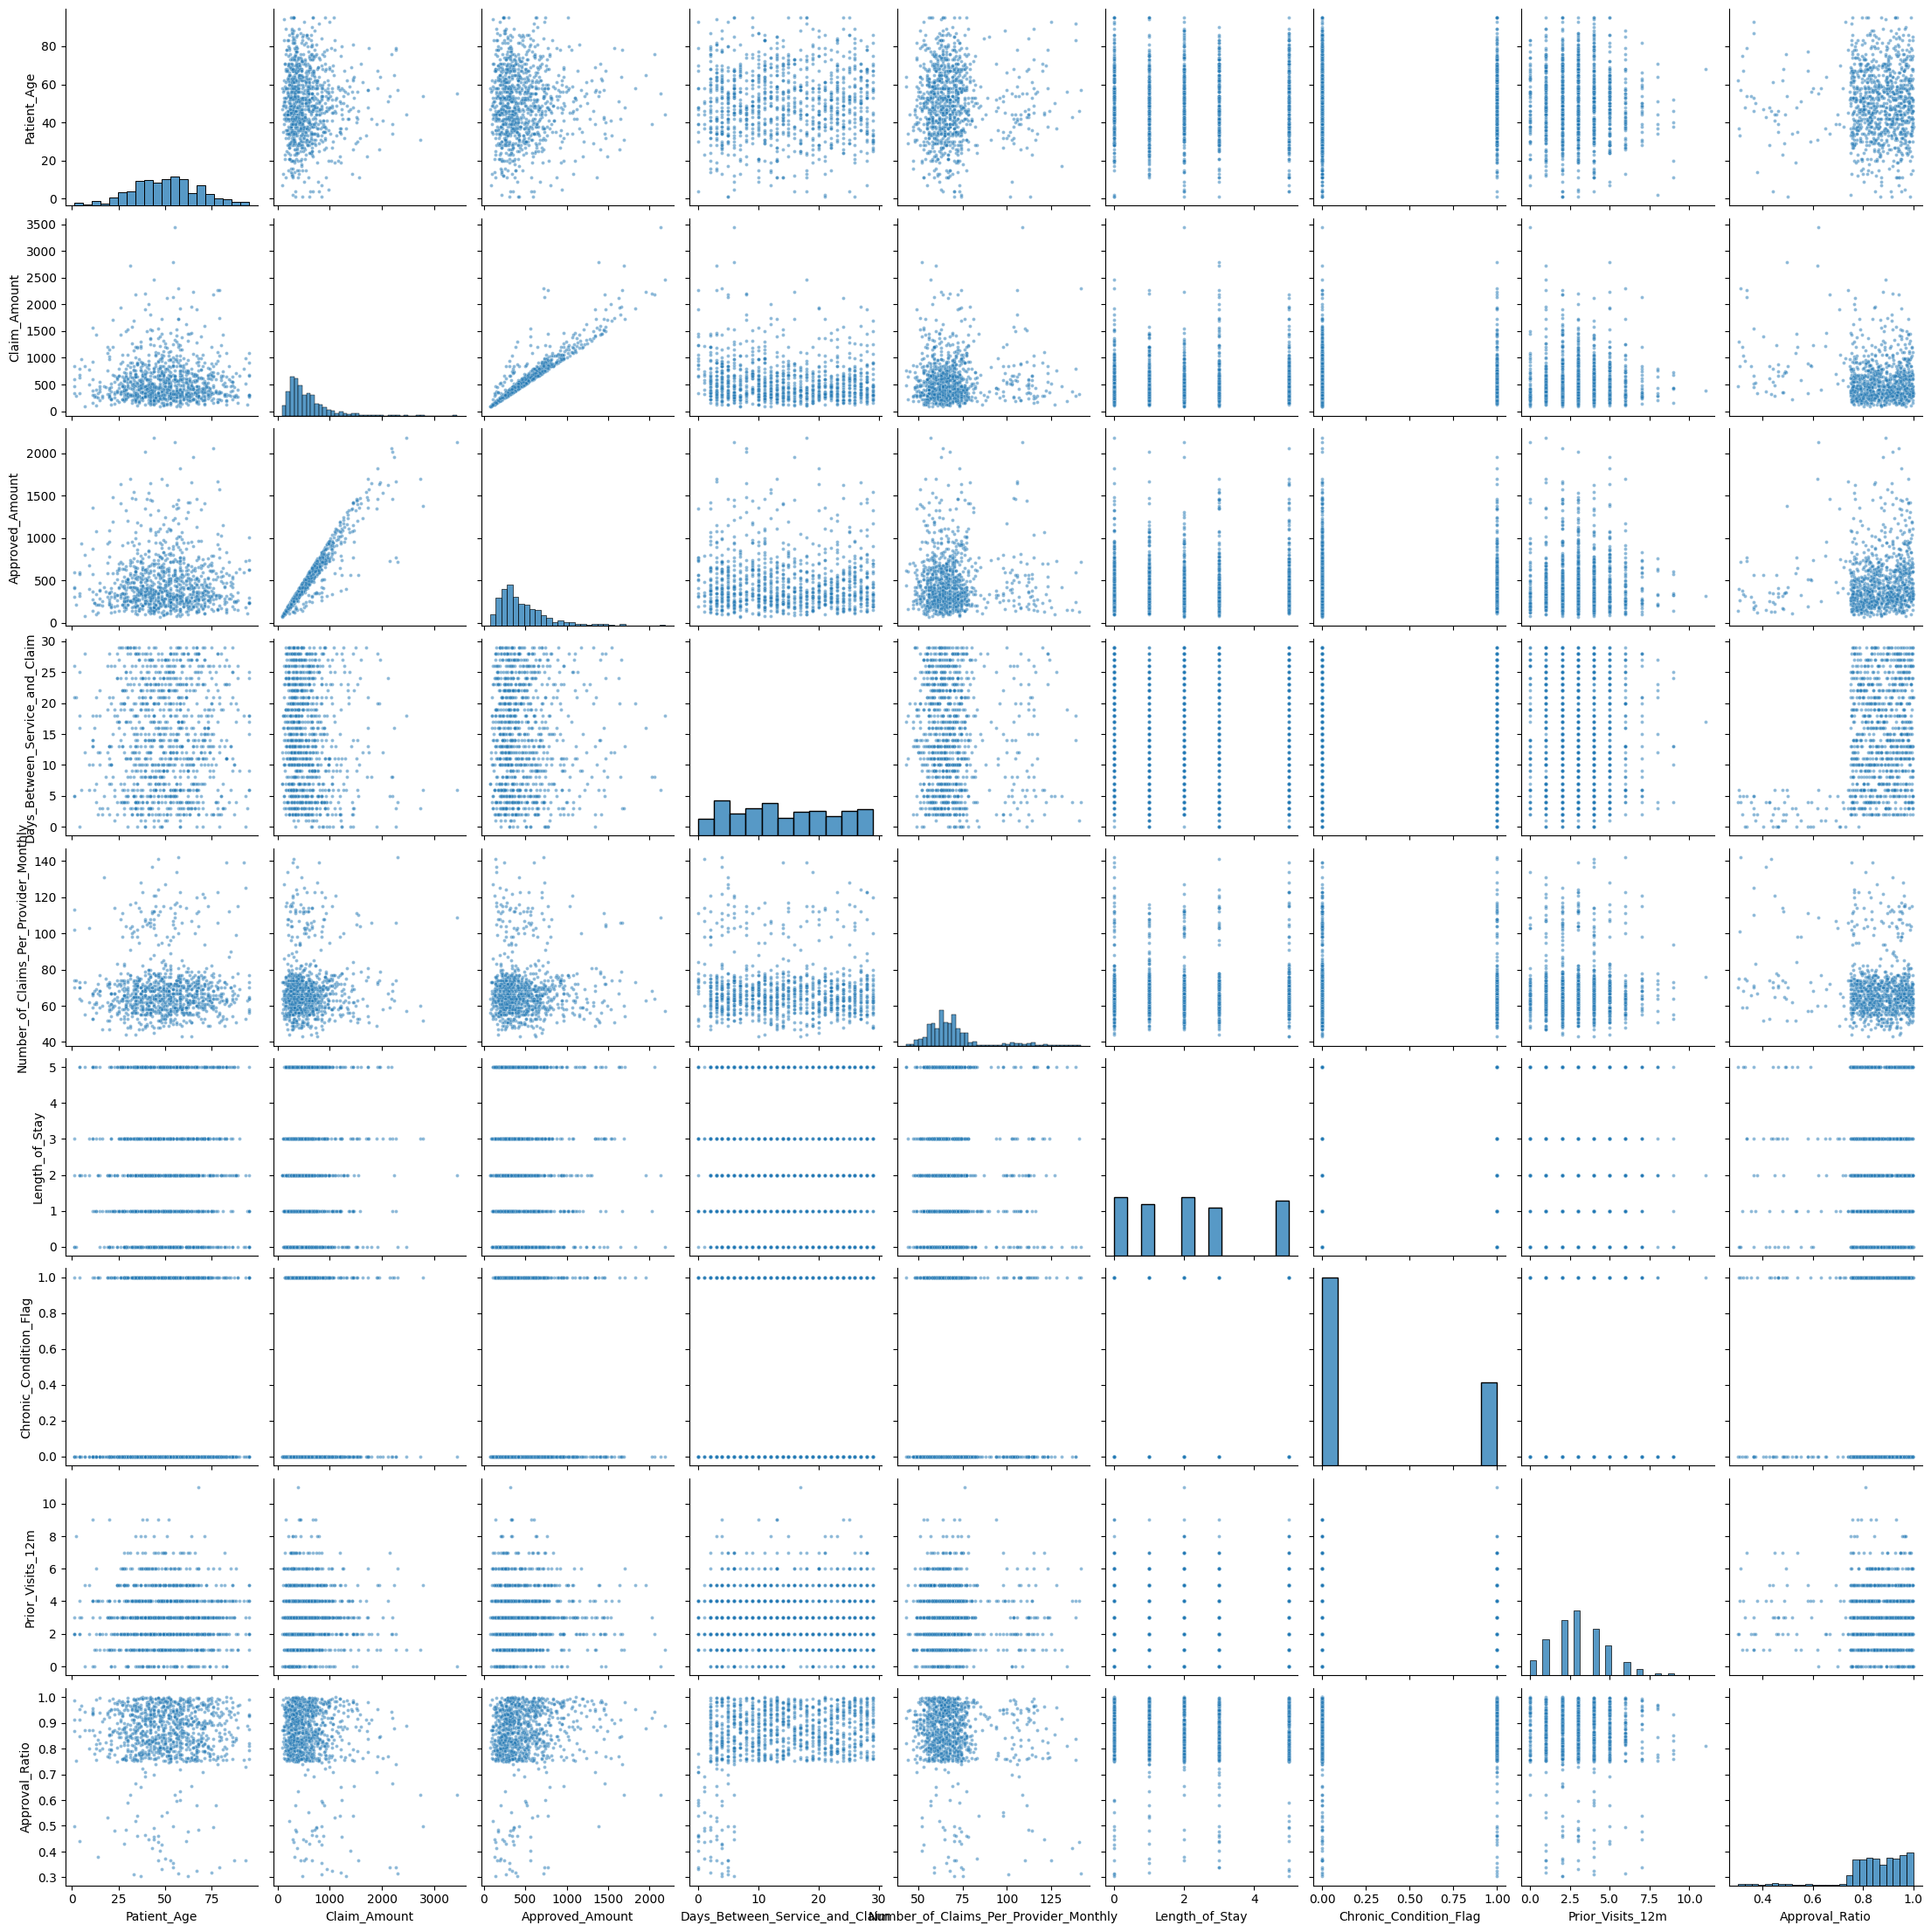

In [38]:
sample = numeric_imputed.sample(1000, random_state=42)
sns.pairplot(sample, plot_kws={'s': 8, 'alpha': 0.5})
plt.show()

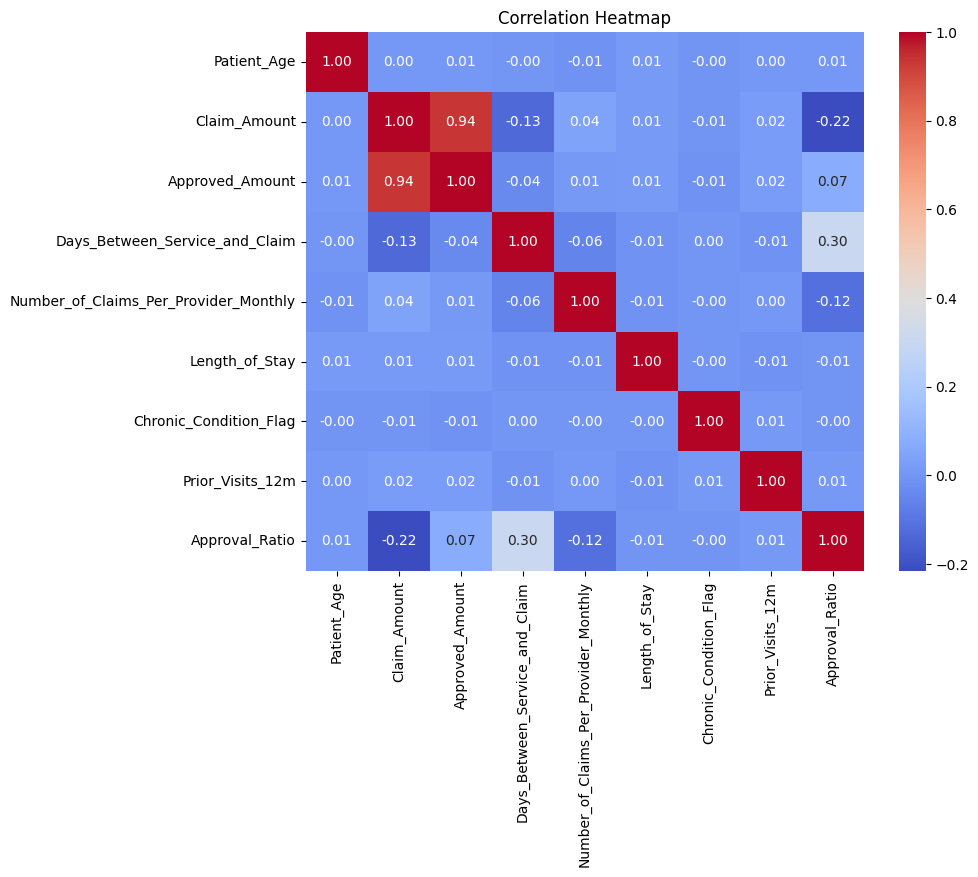

In [39]:
plt.figure(figsize=(9,7))
sns.heatmap(numeric_imputed.corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Conclusion

This project analysed 10,000 healthcare insurance claims with unsupervised methods, with the fraud label removed from every step. The 9 numeric features are almost uncorrelated, so PCA compresses the data only weakly (7 components for 90% of the variance); the two clear components are claim size (PC1) and claim handling (PC2: approval share and submission delay). K-Means and hierarchical clustering split the claims into four business segments (routine claims of non-chronic patients, routine claims of chronic patients, large approved claims, and a small group of fast-submitted, largely rejected claims from high-volume providers), but low silhouette scores show these are segments of a continuum rather than separated groups. The three anomaly detectors agree on 87 claims, very large claims with low approval from busy providers; the Z-score adds single-feature extremes and LOF adds locally unusual but ordinary-sized claims. The consensus set is the natural starting point for a manual fraud review, while the disagreement between methods illustrates that, without labels, "anomalous" is a question of definition rather than a fact in the data.